# 3.Data Preparation

This notebook documents the data preparation stage of the project **Predicting High Health Risk Among Older Adults Using Machine Learning**. The dataset was constructed using selected NHANES 2017–2020 files: `DEMO`, `MCQ`, `BPQ`, `DIQ`, `HUQ`, `CDQ`, and `SMQ`. These files provide information on demographic characteristics, chronic diseases, blood pressure and cholesterol conditions, healthcare utilization, chest pain and cardiovascular symptoms, and smoking-related behaviours. Only respondents aged 60 years and above were retained for this study.

The objective of this notebook is to transform the raw merged data into a final analytical dataset suitable for machine learning modelling. To achieve this, several preprocessing steps were carried out, including data checking, dataset merging, variable screening, missing value inspection, simplified variable selection, variable recoding, construction of a smoking-related predictor, and definition of the target variable.


## 3.1 Check Data and merged

###  3.1.1 Check

In [10]:
import pandas as pd
demo = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/DEMO.xpt", format="xport")
mcq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/MCQ.xpt", format="xport")
bpq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/BPQ.xpt", format="xport")
diq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/DIQ.xpt", format="xport")
huq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/HUQ.xpt", format="xport")
cdq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/CDQ.xpt", format="xport")
smq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/SMQ.xpt", format="xport")

In [11]:
print("demo:", demo.shape) ## Data volume
print("mcq:", mcq.shape)
print("bpq:", bpq.shape)
print("diq:", diq.shape)
print("huq:", huq.shape)
print("cdq:", cdq.shape)
print("smq:", smq.shape)

demo: (15560, 29)
mcq: (14986, 63)
bpq: (10195, 11)
diq: (14986, 28)
huq: (15560, 7)
cdq: (6433, 17)
smq: (11137, 16)


In [12]:
print("SEQN in demo:", "SEQN" in demo.columns) ## check SEQN
print("SEQN in mcq:", "SEQN" in mcq.columns)
print("SEQN in bpq:", "SEQN" in bpq.columns)
print("SEQN in diq:", "SEQN" in diq.columns)
print("SEQN in huq:", "SEQN" in huq.columns)
print("SEQN in cdq:", "SEQN" in cdq.columns)
print("SEQN in smq:", "SEQN" in smq.columns)

SEQN in demo: True
SEQN in mcq: True
SEQN in bpq: True
SEQN in diq: True
SEQN in huq: True
SEQN in cdq: True
SEQN in smq: True


### 3.1.2 merged

In [13]:
## Screening the elderly aged 60 and above
elderly_demo = demo[demo["RIDAGEYR"] >= 60].copy()
print(elderly_demo.shape)
elderly_demo.head()

(3422, 29)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,...,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,WTINTPRP,WTMECPRP,SDMVPSU,SDMVSTRA,INDFMPIR
11,109274.0,66.0,2.0,1.0,68.0,NaN,5.0,7.0,1.0,1.0,...,2.0,1.0,2.0,2.0,1.0,7227.993241,7801.600218,2.0,167.0,1.20
19,109282.0,66.0,2.0,1.0,76.0,NaN,3.0,3.0,2.0,1.0,...,2.0,1.0,2.0,2.0,NaN,28363.015286,31816.346500,2.0,164.0,3.61
27,109290.0,66.0,2.0,2.0,68.0,NaN,4.0,4.0,2.0,1.0,...,2.0,1.0,2.0,2.0,1.0,3967.693106,4099.841985,1.0,171.0,5.00
35,109298.0,66.0,2.0,1.0,68.0,NaN,3.0,3.0,2.0,1.0,...,2.0,1.0,1.0,2.0,NaN,7587.880067,7866.974787,1.0,167.0,1.75
50,109313.0,66.0,2.0,1.0,63.0,NaN,3.0,3.0,1.0,2.0,...,2.0,1.0,2.0,2.0,1.0,89118.344422,101702.788572,1.0,156.0,5.00


In [14]:
merged = elderly_demo.merge(mcq, on="SEQN", how="left")
merged = merged.merge(bpq, on="SEQN", how="left")
merged = merged.merge(diq, on="SEQN", how="left")
merged = merged.merge(huq, on="SEQN", how="left")
merged = merged.merge(cdq, on="SEQN", how="left")
merged = merged.merge(smq, on="SEQN", how="left")
print(merged.shape)
merged.head()

(3422, 165)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,...,SMD057,SMQ078,SMD641,SMD650,SMD100FL,SMD100MN,SMQ670,SMQ621,SMD630,SMAQUEX2
0,109274.0,66.0,2.0,1.0,68.0,NaN,5.0,7.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,109282.0,66.0,2.0,1.0,76.0,NaN,3.0,3.0,2.0,1.0,...,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,109290.0,66.0,2.0,2.0,68.0,NaN,4.0,4.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,109298.0,66.0,2.0,1.0,68.0,NaN,3.0,3.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,109313.0,66.0,2.0,1.0,63.0,NaN,3.0,3.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [15]:
print(merged.columns.tolist())

['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDYRUSZ', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'WTINTPRP', 'WTMECPRP', 'SDMVPSU', 'SDMVSTRA', 'INDFMPIR', 'MCQ010', 'MCQ025', 'MCQ035', 'MCQ040', 'MCQ050', 'AGQ030', 'MCQ053', 'MCQ080', 'MCQ092', 'MCD093', 'MCQ149', 'MCQ151', 'RHD018', 'MCQ160A', 'MCQ195', 'MCQ160B', 'MCD180B', 'MCQ160C', 'MCD180C', 'MCQ160D', 'MCD180D', 'MCQ160E', 'MCD180E', 'MCQ160F', 'MCD180F', 'MCQ160M', 'MCQ170M', 'MCD180M', 'MCQ160P', 'MCQ160L', 'MCQ170L', 'MCD180L', 'MCQ500', 'MCQ510A', 'MCQ510B', 'MCQ510C', 'MCQ510D', 'MCQ510E', 'MCQ510F', 'MCQ520', 'MCQ530', 'MCQ540', 'MCQ550', 'MCQ560', 'MCQ570', 'MCQ220', 'MCQ230A', 'MCQ230B', 'MCQ230C', 'MCQ230D', 'MCQ300B', 'MCQ300C', 'MCQ300A', 'MCQ366A', 'MCQ366B', 'MCQ366C', 'MCQ366D', 'MCQ371A', 'MCQ371B', 'MCQ371C', 'MCQ371D', 'OSQ230', 

## 3.2 Full Variables and Codebook Descriptions

### 3.2.1 Demographic Variables

| Variable | Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Unique respondent identifier used for merging datasets |
| SDDSRVYR | Data release cycle | Survey cycle information |
| RIDSTATR | Interview/Examination status | Participant interview and examination status |
| RIAGENDR | Gender | Demographic feature |
| RIDAGEYR | Age in years at screening | Used to filter participants aged 65 and above |
| RIDAGEMN | Age in months at screening (0 to 24 months) | Applicable mainly to infants/young children |
| RIDRETH1 | Race/Hispanic origin | Demographic feature |
| RIDRETH3 | Race/Hispanic origin with NH Asian | Detailed race/ethnicity classification |
| RIDEXMON | Six-month time period | Examination timing indicator |
| DMDBORN4 | Country of birth | Demographic background variable |
| DMDYRUSZ | Length of time in US | Immigration-related background variable |
| DMDEDUC2 | Education level - Adults 20+ | Socioeconomic feature |
| DMDMARTZ | Marital status | Demographic and social feature |
| RIDEXPRG | Pregnancy status at exam | Health status indicator |
| SIALANG | Language of SP Interview | Interview language information |
| SIAPROXY | Proxy used in SP Interview? | Interview administration feature |
| SIAINTRP | Interpreter used in SP Interview? | Interview administration feature |
| FIALANG | Language of Family Interview | Interview language information |
| FIAPROXY | Proxy used in Family Interview? | Interview administration feature |
| FIAINTRP | Interpreter used in Family Interview? | Interview administration feature |
| MIALANG | Language of MEC Interview | MEC interview language information |
| MIAPROXY | Proxy used in MEC Interview? | MEC interview administration feature |
| MIAINTRP | Interpreter used in MEC Interview? | MEC interview administration feature |
| AIALANGA | Language of ACASI Interview | ACASI interview language information |
| WTINTPRP | Full sample interview weight | Survey weighting variable |
| WTMECPRP | Full sample MEC exam weight | Survey weighting variable |
| SDMVPSU | Masked variance pseudo-PSU | Survey design variable |
| SDMVSTRA | Masked variance pseudo-stratum | Survey design variable |
| INDFMPIR | Ratio of family income to poverty | Socioeconomic feature |

### 3.2.2 Blood Pressure and Cholesterol Variables

| Variable | Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Used for merging datasets |
| BPQ020 | Ever told you had high blood pressure | Representative hypertension variable |
| BPQ030 | Told had high blood pressure - 2+ times | Hypertension confirmation variable |
| BPD035 | Age told had hypertension | Age at hypertension diagnosis |
| BPQ040A | Taking prescription for hypertension | Hypertension treatment variable |
| BPQ050A | Now taking prescribed medicine for HBP | Current hypertension medication use |
| BPQ080 | Doctor told you - high cholesterol level | Representative high cholesterol variable |
| BPQ060 | Ever had blood cholesterol checked | Cholesterol screening history |
| BPQ070 | When blood cholesterol last checked | Recency of cholesterol check |
| BPQ090D | Told to take prescription for cholesterol | Cholesterol treatment recommendation |
| BPQ100D | Now taking prescribed medicine | Current cholesterol medication use |

### 3.2.3 Chest Pain and Cardiovascular Symptom Variables

| Variable | Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Used for merging datasets |
| CDQ001 | SP ever had pain or discomfort in chest | Chest pain screening variable |
| CDQ002 | SP get it walking uphill or in a hurry | Symptom under exertion |
| CDQ003 | During an ordinary pace on level ground | Symptom during normal walking |
| CDQ003A | CHECK ITEM | Questionnaire routing/check item |
| CDQ004 | If so does SP continue or slow down | Symptom response behaviour |
| CDQ005 | Does standing relieve pain/discomfort | Pain relief behaviour |
| CDQ006 | How soon is the pain relieved | Pain duration indicator |
| CDQ009A | Pain in right arm | Symptom location variable |
| CDQ009B | Pain in right chest | Symptom location variable |
| CDQ009C | Pain in neck | Symptom location variable |
| CDQ009D | Pain in upper sternum | Symptom location variable |
| CDQ009E | Pain in lower sternum | Symptom location variable |
| CDQ009F | Pain in left chest | Symptom location variable |
| CDQ009G | Pain in left arm | Symptom location variable |
| CDQ009H | Pain in epigastric area | Symptom location variable |
| CDQ008 | Severe pain in chest more than half hour | Severe chest pain indicator |
| CDQ010 | Shortness of breath on stairs/inclines | Functional cardiovascular symptom |

### 3.2.4 Diabetes Variables

| Variable | Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Used for merging datasets |
| DIQ010 | Doctor told you have diabetes | Representative diabetes variable |
| DID040 | Age when first told you had diabetes | Age at diabetes diagnosis |
| DIQ159 | CHECK ITEM | Questionnaire routing/check item |
| DIQ160 | Ever told you have prediabetes | Prediabetes variable |
| DIQ180 | Had blood tested past three years | Diabetes screening history |
| DIQ050 | Taking insulin now | Diabetes treatment variable |
| DID060 | How long taking insulin | Duration of insulin treatment |
| DIQ060U | Unit of measure (month/year) | Unit for insulin duration |
| DIQ065 | CHECK ITEM | Questionnaire routing/check item |
| DIQ070 | Take diabetic pills to lower blood sugar | Diabetes medication use |
| DIQ229 | CHECK ITEM | Questionnaire routing/check item |
| DIQ230 | How long ago saw a diabetes specialist | Specialist care recency |
| DIQ240 | Is there one Dr you see for diabetes | Continuity of diabetes care |
| DID250 | Past year how many times seen doctor | Healthcare utilization related to diabetes |
| DID260 | How often check blood for glucose/sugar | Self-monitoring behaviour |
| DIQ260U | Unit of measure (day/week/month/year) | Unit for glucose monitoring frequency |
| DIQ275 | Past year Dr checked for A1C | A1C monitoring history |
| DIQ280 | What was your last A1C level | Clinical diabetes management variable |
| DIQ291 | What does Dr say A1C should be | Recommended A1C target |
| DIQ295 | CHECK ITEM | Questionnaire routing/check item |
| DIQ300S | What was your recent SBP | Recent systolic blood pressure |
| DIQ300D | What was your recent DBP | Recent diastolic blood pressure |
| DID310S | What does Dr say SBP should be | Recommended systolic blood pressure |
| DID310D | What does Dr say DBP should be | Recommended diastolic blood pressure |
| DID320 | What was most recent LDL number | Recent LDL cholesterol |
| DID330 | What does Dr say LDL should be | Recommended LDL cholesterol |
| DID341 | Past year times Dr check feet for sores | Diabetes foot care monitoring |
| DID350 | How often do you check your feet | Self foot-care behaviour |
| DIQ350U | Unit of measure (day/week/month/year) | Unit for foot-check frequency |
| DIQ360 | Last time had pupils dilated for exam | Eye examination history |

### 3.2.5 Healthcare Utilization Variables

| Variable | Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Used for merging datasets |
| HUQ010 | General health condition | Used as a health status variable / proxy target in some analyses |
| HUQ030 | Routine place to go for healthcare | Healthcare access variable |
| HUQ051 | #times receive healthcare over past year | Potential healthcare utilization target variable |
| HUD062 | How long since last healthcare visit | Healthcare recency indicator |
| HUQ071 | Overnight hospital patient in last year | Hospitalization variable |
| HUQ085 | CHECK ITEM | Questionnaire routing/check item |
| HUQ090 | Seen mental health professional/past yr | Mental healthcare utilization variable |

### 3.2.6 Medical Conditions Variables

| Variable | Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Used for merging datasets |
| MCQ010 | Ever been told you have asthma | Respiratory disease history |
| MCQ025 | Age when first had asthma | Age at asthma diagnosis |
| MCQ035 | Still have asthma | Current asthma status |
| MCQ040 | Had asthma attack in past year | Asthma severity indicator |
| MCQ050 | Emergency care visit for asthma/past yr | Asthma-related healthcare use |
| AGQ030 | Did SP have episode of hay fever/past yr | Allergy-related condition |
| MCQ053 | Taking treatment for anemia/past 3 mos | Anemia treatment variable |
| MCQ080 | Doctor ever said you were overweight | Weight-related health history |
| MCQ092 | Ever receive blood transfusion | Medical history variable |
| MCD093 | Year receive blood transfusion | Timing of transfusion |
| MCQ145 | CHECK ITEM | Questionnaire routing/check item |
| MCQ149 | Menstrual periods started yet? | Reproductive health variable |
| MCQ151 | Age in years at first menstrual period | Reproductive health history |
| RHD018 | Estimated age in months at menarche | Reproductive health history |
| MCQ160A | Doctor ever said you had arthritis | Representative arthritis variable |
| MCQ195 | Which type of arthritis was it? | Arthritis subtype |
| MCQ160B | Ever told had congestive heart failure | Cardiovascular disease variable |
| MCD180B | Age when told you had heart failure | Age at diagnosis |
| MCQ160C | Ever told you had coronary heart disease | Cardiovascular disease variable |
| MCD180C | Age when told had coronary heart disease | Age at diagnosis |
| MCQ160D | Ever told you had angina/angina pectoris | Cardiovascular disease variable |
| MCD180D | Age when told had angina pectoris | Age at diagnosis |
| MCQ160E | Ever told you had heart attack | Cardiovascular disease variable |
| MCD180E | Age when told you had heart attack | Age at diagnosis |
| MCQ160F | Ever told you had a stroke | Cardiovascular / neurological disease variable |
| MCD180F | Age when told you had a stroke | Age at diagnosis |
| MCQ160M | Ever told you had thyroid problem | Thyroid disease history |
| MCQ170M | Do you still have thyroid problem | Current thyroid problem status |
| MCD180M | Age when told you had thyroid problem | Age at diagnosis |
| MCQ160P | Ever told you had COPD, emphysema, chronic bronchitis | Representative respiratory disease variable |
| MCQ160L | Ever told you had any liver condition | Liver disease history |
| MCQ170L | Do you still have a liver condition | Current liver disease status |
| MCD180L | Age when told you had a liver condition | Age at diagnosis |
| MCQ500 | Ever told you had any liver condition | Additional liver disease indicator |
| MCQ510A | Liver condition: Fatty liver | Liver disease subtype |
| MCQ510B | Liver condition: Liver fibrosis | Liver disease subtype |
| MCQ510C | Liver condition: Liver cirrhosis | Liver disease subtype |
| MCQ510D | Liver condition: Viral hepatitis | Liver disease subtype |
| MCQ510E | Liver condition: Autoimmune hepatitis | Liver disease subtype |
| MCQ510F | Liver condition: Other liver disease | Liver disease subtype |
| MCQ515 | CHECK ITEM | Questionnaire routing/check item |
| MCQ520 | Abdominal pain during past 12 months? | Symptom variable |
| MCQ530 | Where was the most uncomfortable pain | Symptom location variable |
| MCQ540 | Ever seen a DR about this pain | Healthcare-seeking behaviour |
| MCQ550 | Has DR ever said you have gallstones | Gallstone history |
| MCQ560 | Ever had gallbladder surgery? | Surgical history |
| MCQ570 | Age when 1st had gallbladder surgery? | Age at surgery |
| MCQ220 | Ever told you had cancer or malignancy | Representative cancer variable |
| MCQ230A | 1st cancer - what kind was it? | Cancer subtype |
| MCQ230B | 2nd cancer - what kind was it? | Cancer subtype |
| MCQ230C | 3rd cancer - what kind was it? | Cancer subtype |
| MCQ230D | More than 3 kinds of cancer | Cancer history complexity |
| MCQ300B | Close relative had asthma? | Family history variable |
| MCQ300C | Close relative had diabetes? | Family history variable |
| MCQ300A | Close relative had heart attack? | Family history variable |
| MCQ366A | Doctor told you to control/lose weight | Lifestyle advice |
| MCQ366B | Doctor told you to exercise | Lifestyle advice |
| MCQ366C | Doctor told you to reduce salt in diet | Lifestyle advice |
| MCQ366D | Doctor told you to reduce fat/calories | Lifestyle advice |
| MCQ371A | Are you now controlling or losing weight | Lifestyle behaviour |
| MCQ371B | Are you now increasing exercise | Lifestyle behaviour |
| MCQ371C | Are you now reducing salt in diet | Lifestyle behaviour |
| MCQ371D | Are you now reducing fat in diet | Lifestyle behaviour |
| OSQ230 | Any metal objects inside your body? |

### 3.2.7 Smoking Variables

| Variable | Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Used for merging datasets |
| SMQ020 | Smoked at least 100 cigarettes in life | Smoking history variable |
| SMD030 | Age started smoking cigarettes regularly | Smoking initiation history |
| SMQ040 | Do you now smoke cigarettes? | Current smoking status variable |
| SMQ050Q | How long since quit smoking cigarettes | Smoking cessation variable |
| SMQ050U | Unit of measure (day/week/month/year) | Unit for quitting duration |
| SMD057 | # cigarettes smoked per day when quit | Past smoking intensity |
| SMQ078 | How soon after waking do you smoke | Nicotine dependence indicator |
| SMD641 | # days smoked cigs during past 30 days | Smoking frequency variable |
| SMD650 | Avg # cigarettes/day during past 30 days | Smoking intensity variable |
| SMD100FL | Cigarette Filter type | Cigarette product characteristic |
| SMD100MN | Cigarette Menthol indicator | Cigarette product characteristic |
| SMQ670 | Tried to quit smoking | Smoking cessation attempt |
| SMQ621 | Cigarettes smoked in entire life | Lifetime smoking exposure |
| SMD630 | Age first smoked whole cigarette | Smoking initiation history |
| SMAQUEX2 | Questionnaire Mode Flag | Survey administration variable |

## 3.3 Initial Variable Screening

After merging the selected NHANES 2017–2020 datasets, an initial variable screening step was conducted. A total of 40 candidate variables were retained based on their relevance to the study objective. These variables included demographic variables, chronic disease variables, blood pressure and cholesterol variables, diabetes variables, smoking-related variables, chest symptom variables, and healthcare utilization variables.

The purpose of this step was to reduce the complexity of the merged dataset while keeping variables that may help explain health risk and healthcare demand among older adults. These candidate variables were then used for missing value inspection before further simplification.

In [21]:
# Keep 40 candidate variables for further missing value inspection

keep_cols = [
    'SEQN',

    # Demographic variables (6)
    'RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'DMDEDUC2', 'DMDMARTZ', 'INDFMPIR',

    # Medical condition variables (14)
    'MCQ160A', 'MCQ160B', 'MCQ160C', 'MCQ160D', 'MCQ160E', 'MCQ160F',
    'MCQ160M', 'MCQ160P', 'MCQ160L', 'MCQ220', 'MCQ053', 'MCQ080',
    'MCQ300B', 'MCQ300C',

    # Blood pressure and cholesterol variables (4)
    'BPQ020', 'BPQ030', 'BPQ080', 'BPQ090D',

    # Diabetes variables (5)
    'DIQ010', 'DIQ160', 'DIQ050', 'DIQ070', 'DIQ080',

    # Smoking variables (3)
    'SMQ020', 'SMQ040', 'SMD641',

    # Chest symptom variables (2)
    'CDQ001', 'CDQ010',

    # Healthcare utilization variables (5)
    'HUQ010', 'HUQ030', 'HUQ051', 'HUQ071', 'HUQ090'
]

selected = merged[keep_cols].copy()

print(f"Selected dataset shape: {selected.shape}")
selected.head()

Selected dataset shape: (3422, 40)


,SEQN,RIAGENDR,RIDAGEYR,RIDRETH1,DMDEDUC2,DMDMARTZ,INDFMPIR,MCQ160A,MCQ160B,MCQ160C,...,SMQ020,SMQ040,SMD641,CDQ001,CDQ010,HUQ010,HUQ030,HUQ051,HUQ071,HUQ090
0,109274.0,1.0,68.0,5.0,4.0,3.0,1.20,1.0,2.0,2.0,...,2.0,NaN,NaN,2.0,2.0,3.0,1.0,5.397605e-79,2.0,2.0
1,109282.0,1.0,76.0,3.0,5.0,1.0,3.61,2.0,2.0,2.0,...,1.0,3.0,NaN,1.0,1.0,4.0,1.0,8.000000e+00,2.0,2.0
2,109290.0,2.0,68.0,4.0,5.0,2.0,5.00,1.0,2.0,2.0,...,2.0,NaN,NaN,2.0,2.0,3.0,1.0,2.000000e+00,2.0,2.0
3,109298.0,1.0,68.0,3.0,1.0,1.0,1.75,1.0,2.0,2.0,...,2.0,NaN,NaN,1.0,1.0,4.0,1.0,4.000000e+00,2.0,2.0
4,109313.0,1.0,63.0,3.0,4.0,1.0,5.00,1.0,2.0,2.0,...,2.0,NaN,NaN,1.0,1.0,3.0,1.0,3.000000e+00,1.0,2.0


## 3.4 Missing Value Inspection

In [23]:
# Check missing values for the 40 candidate variables
missing = selected.isnull().sum().sort_values(ascending=False)
print(missing)

SMD641      2970
DIQ080      2490
DIQ050      2488
DIQ070      1954
SMQ040      1737
BPQ030      1322
DIQ160      1075
INDFMPIR     538
BPQ090D      304
CDQ010         0
CDQ001         0
HUQ010         0
BPQ020         0
SMQ020         0
HUQ030         0
HUQ051         0
HUQ071         0
DIQ010         0
BPQ080         0
SEQN           0
MCQ300C        0
RIAGENDR       0
MCQ160D        0
RIDAGEYR       0
RIDRETH1       0
DMDEDUC2       0
DMDMARTZ       0
MCQ160A        0
MCQ160B        0
MCQ160C        0
MCQ160E        0
MCQ300B        0
MCQ160F        0
MCQ160M        0
MCQ160P        0
MCQ160L        0
MCQ220         0
MCQ053         0
MCQ080         0
HUQ090         0
dtype: int64


Missing values were inspected for the 40 candidate variables before further simplification. This step was carried out to identify variables with substantial missingness and to provide evidence for the later variable reduction process.

### Figure1:Missing Value Pattern

The merged dataset initially contained 118 variables. To reduce complexity and focus on variables relevant to the study objective, an initial variable screening step was performed. Variables related to demographic characteristics, chronic diseases, blood pressure and cholesterol, diabetes, smoking, chest symptoms, and healthcare utilization were retained for further analysis. As a result, 40 candidate variables were selected for the next stage of preprocessing.

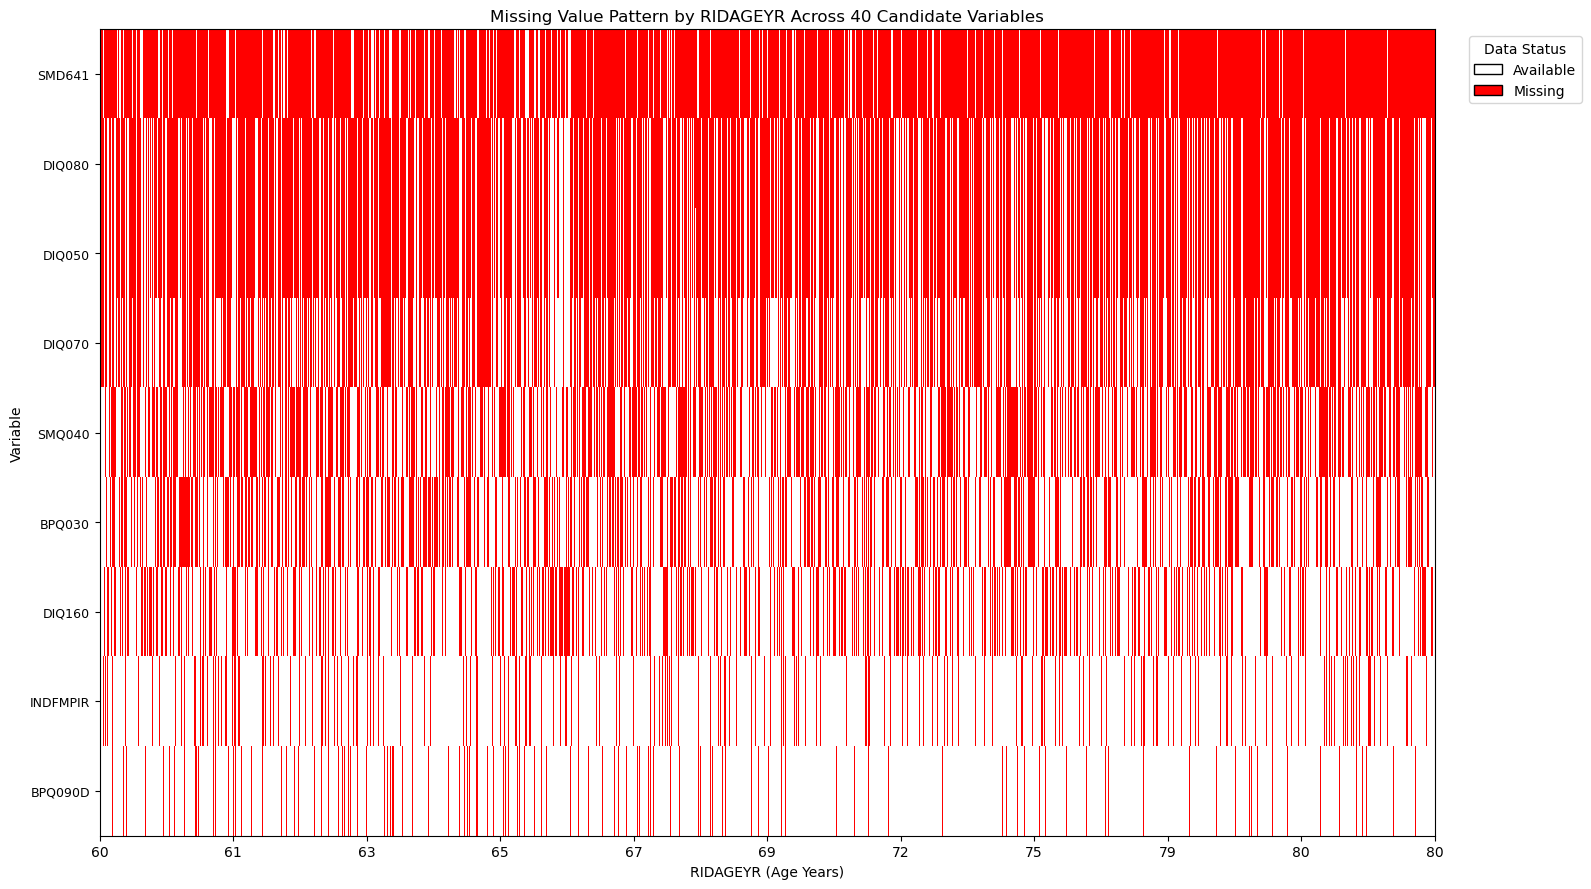

In [24]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Step 1: calculate missing values for the 40 candidate variables
missing = selected.isnull().sum().sort_values(ascending=False)

# Step 2: keep only variables with missing values
plot_vars = missing[missing > 0].index.tolist()

# Remove ID variable if it appears
if 'SEQN' in plot_vars:
    plot_vars.remove('SEQN')

# RIDAGEYR will be used on the x-axis, so remove it from y-axis variables
if 'RIDAGEYR' in plot_vars:
    plot_vars.remove('RIDAGEYR')

# Step 3: create plotting dataframe
plot_df = selected[['RIDAGEYR'] + plot_vars].copy()

# Step 4: sort by age
plot_df = plot_df.sort_values(by='RIDAGEYR').reset_index(drop=True)

# Step 5: create missing-value matrix
# missing = 1, available = 0
missing_matrix = plot_df.drop(columns=['RIDAGEYR']).isnull().T.astype(int)

# Step 6: define colors
# white = available, red = missing
cmap = ListedColormap(['white', 'red'])

# Step 7: plot
plt.figure(figsize=(16, 9))
plt.imshow(missing_matrix, aspect='auto', interpolation='none', cmap=cmap)

# y-axis labels
plt.yticks(range(len(missing_matrix.index)), missing_matrix.index, fontsize=9)

# x-axis labels based on age
x_positions = range(0, len(plot_df), max(1, len(plot_df)//10))
x_labels = plot_df.loc[list(x_positions), 'RIDAGEYR'].astype(int).tolist()
plt.xticks(x_positions, x_labels)

plt.xlabel('RIDAGEYR (Age Years)')
plt.ylabel('Variable')
plt.title('Missing Value Pattern by RIDAGEYR Across 40 Candidate Variables')

# legend
legend_elements = [
    Patch(facecolor='white', edgecolor='black', label='Available'),
    Patch(facecolor='red', edgecolor='black', label='Missing')
]
plt.legend(handles=legend_elements, title='Data Status',
           bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

This figure shows the missing value pattern across the candidate variables with missingness in the 40-variable set. The x-axis represents participant age (`RIDAGEYR`), and the y-axis represents variables. Red cells indicate missing values, while white cells indicate available data. The figure helps identify variables with substantial missingness and shows whether missingness is concentrated in particular age ranges.

## 3.5 Simplified Variable Selection

After the missing value inspection, the variable list was further reduced from 40 candidate variables to a smaller set of representative variables. This reduction was based on three principles: keeping variables with relatively low missingness, retaining clinically meaningful variables, and avoiding overly detailed variables that could reduce interpretability.

For the MCQ dataset, arthritis (`MCQ160A`), COPD (`MCQ160P`), and cancer (`MCQ220`) were retained as separate variables because they represent major chronic disease categories among older adults. Several cardiovascular disease variables — congestive heart failure (`MCQ160B`), coronary heart disease (`MCQ160C`), angina (`MCQ160D`), heart attack (`MCQ160E`), and stroke (`MCQ160F`) — were also retained at this stage and were planned to be combined later during the recoding step.

As a result, the simplified dataset retained demographic variables, selected chronic disease indicators, chest symptom variables, smoking-related variables, and `HUQ051` as the potential target variable for later modelling.

In [26]:
# Keep simplified variables for later recoding and modelling

keep_cols_simple = [
    'SEQN',

    # Demographic variables
    'RIAGENDR',
    'RIDAGEYR',
    'RIDRETH1',
    'DMDEDUC2',
    'DMDMARTZ',
    'INDFMPIR',

    # Blood pressure / cholesterol
    'BPQ020',
    'BPQ080',

    # Diabetes
    'DIQ010',

    # MCQ variables
    'MCQ160A',  # arthritis
    'MCQ160B',  # heart failure
    'MCQ160C',  # coronary heart disease
    'MCQ160D',  # angina
    'MCQ160E',  # heart attack
    'MCQ160F',  # stroke
    'MCQ160P',  # COPD
    'MCQ220',   # cancer

    # Chest symptoms
    'CDQ001',
    'CDQ010',

    # Smoking
    'SMQ020',
    'SMQ040',

    # Potential target
    'HUQ051'
]

selected_simple = merged[keep_cols_simple].copy()

print("Selected simplified dataset shape:", selected_simple.shape)
selected_simple.head()

Selected simplified dataset shape: (3422, 23)


,SEQN,RIAGENDR,RIDAGEYR,RIDRETH1,DMDEDUC2,DMDMARTZ,INDFMPIR,BPQ020,BPQ080,DIQ010,...,MCQ160D,MCQ160E,MCQ160F,MCQ160P,MCQ220,CDQ001,CDQ010,SMQ020,SMQ040,HUQ051
0,109274.0,1.0,68.0,5.0,4.0,3.0,1.20,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,5.397605e-79
1,109282.0,1.0,76.0,3.0,5.0,1.0,3.61,1.0,1.0,2.0,...,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,3.0,8.000000e+00
2,109290.0,2.0,68.0,4.0,5.0,2.0,5.00,1.0,2.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,2.000000e+00
3,109298.0,1.0,68.0,3.0,1.0,1.0,1.75,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,NaN,4.000000e+00
4,109313.0,1.0,63.0,3.0,4.0,1.0,5.00,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,NaN,3.000000e+00


### 3.5.1 Demographic Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Unique respondent identifier used for merging datasets |
| RIAGENDR | Gender | Demographic feature |
| RIDAGEYR | Age in years at screening | Used to retain participants aged 60 and above |
| RIDRETH1 | Race/Hispanic origin | Demographic feature |
| DMDEDUC2 | Education level - Adults 20+ | Socioeconomic feature |
| DMDMARTZ | Marital status | Demographic and social feature |
| INDFMPIR | Ratio of family income to poverty | Socioeconomic feature |

### 3.5.2 Healthcare Utilization Variable

| Variable | Codebook Description | Notes |
|---|---|---|
| HUQ051 | #times receive healthcare over past year | Used as the target-related healthcare utilization variable in this study |

### 3.5.3 Disease Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| DIQ010 | Doctor told you have diabetes | Representative diabetes variable |
| BPQ020 | Ever told you had high blood pressure | Representative hypertension variable |
| BPQ080 | Doctor told you - high cholesterol level | Representative high cholesterol variable |
| MCQ160A | Doctor ever said you had arthritis | Representative arthritis variable |
| MCQ160P | Ever told you had COPD, emphysema, chronic bronchitis | Representative respiratory disease variable |
| MCQ220 | Ever told you had cancer or malignancy | Representative cancer variable |

### 3.5.4 Cardiovascular Disease Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| MCQ160B | Ever told had congestive heart failure | Cardiovascular disease variable |
| MCQ160C | Ever told you had coronary heart disease | Cardiovascular disease variable |
| MCQ160D | Ever told you had angina/angina pectoris | Cardiovascular disease variable |
| MCQ160E | Ever told you had heart attack | Cardiovascular disease variable |
| MCQ160F | Ever told you had a stroke | Cardiovascular / neurological disease variable |

### 3.5.5 Chest Symptom Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| CDQ001 | SP ever had pain or discomfort in chest | Chest symptom variable |
| CDQ010 | Shortness of breath on stairs/inclines | Chest / cardiovascular symptom variable |

### 3.5.6 Smoking Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| SMQ020 | Smoked at least 100 cigarettes in life | Smoking history variable |
| SMQ040 | Do you now smoke cigarettes? | Current smoking status variable |

## 3.6 Variable Recoding and Target Construction

After the simplified variable selection step, the retained variables were recoded to prepare the dataset for modelling. Common special response codes such as `7`, `9`, and `99` were treated as missing values.

Binary questionnaire variables were recoded into a consistent `1 = Yes` and `0 = No` format. A new smoking-related variable, `smoking_status`, was constructed using both `SMQ020` and `SMQ040` to reduce the impact of skip patterns.

In addition, five cardiovascular disease variables — `MCQ160B`, `MCQ160C`, `MCQ160D`, `MCQ160E`, and `MCQ160F` — were combined into one new binary variable, `cardio_disease`, in order to reduce redundancy and improve model interpretability.

Finally, `HUQ051` was retained as the target-related variable for later target construction.

###  3.6.1 Variable Recoding

In [30]:
import pandas as pd

# 1. Replace common special response codes with missing values
selected_simple = selected_simple.replace({
    7: pd.NA, 9: pd.NA, 99: pd.NA,
    7.0: pd.NA, 9.0: pd.NA, 99.0: pd.NA
})

# 2. Recode binary yes/no variables into 1 = Yes, 0 = No
yes_no_cols = [
    'BPQ020',
    'BPQ080',
    'DIQ010',
    'MCQ160A',
    'MCQ160B',
    'MCQ160C',
    'MCQ160D',
    'MCQ160E',
    'MCQ160F',
    'MCQ160P',
    'MCQ220',
    'CDQ001',
    'CDQ010'
]

for col in yes_no_cols:
    selected_simple[col] = selected_simple[col].replace({
        1.0: 1,
        2.0: 0
    })

# 3. Construct smoking_status using SMQ020 and SMQ040
selected_simple['smoking_status'] = pd.NA

selected_simple.loc[selected_simple['SMQ040'].isin([1.0, 2.0]), 'smoking_status'] = 1
selected_simple.loc[selected_simple['SMQ040'] == 3.0, 'smoking_status'] = 0
selected_simple.loc[selected_simple['SMQ020'] == 2.0, 'smoking_status'] = 0

# 4. Combine cardiovascular disease variables
selected_simple['cardio_disease'] = (
    (selected_simple['MCQ160B'] == 1) |
    (selected_simple['MCQ160C'] == 1) |
    (selected_simple['MCQ160D'] == 1) |
    (selected_simple['MCQ160E'] == 1) |
    (selected_simple['MCQ160F'] == 1)
).astype('Int64')

# 5. Quick check
print(selected_simple[['MCQ160B', 'MCQ160C', 'MCQ160D', 'MCQ160E', 'MCQ160F', 'cardio_disease']].head())
print("\ncardio_disease distribution:")
print(selected_simple['cardio_disease'].value_counts(dropna=False))

print("\nsmoking_status distribution:")
print(selected_simple['smoking_status'].value_counts(dropna=False))

  MCQ160B MCQ160C MCQ160D MCQ160E MCQ160F  cardio_disease
0       0       0       0       0       0               0
1       0       0       0       0       0               0
2       0       0       0       0       0               0
3       0       0       0       0       0               0
4       0       0       0       0       0               0

cardio_disease distribution:
cardio_disease
0    2549
1     873
Name: count, dtype: Int64

smoking_status distribution:
smoking_status
0       2967
1        452
<NA>       3
Name: count, dtype: int64




| Variable | Description | Notes |
|---|---|---|
| smoking_status | Derived smoking-related predictor | Constructed using SMQ020 and SMQ040 |
| cardio_disease | Derived cardiovascular disease indicator | Combined from MCQ160B, MCQ160C, MCQ160D, MCQ160E, and MCQ160F |
| target | Higher healthcare demand indicator | Constructed later using HUQ051 |

###  3.6.2  Target Construction

In this study, `HUQ051` was used to construct the target variable because it reflects the number of healthcare visits received over the past year. To simplify the modelling task, it was transformed into a binary outcome.

Participants with `HUQ051` values of `4` or above were classified as the higher healthcare demand group (`target = 1`), while those with values below `4` were classified as the lower healthcare demand group (`target = 0`).

This cut-off was chosen to distinguish participants with relatively frequent healthcare utilization from those with lower or moderate healthcare use, while still keeping a reasonable class distribution for classification modelling.

In [32]:
print(selected_simple['HUQ051'].value_counts(dropna=False).sort_index())

HUQ051
0.0      219
1.0      419
2.0     1062
3.0      681
4.0      350
5.0      153
6.0      259
8.0      191
<NA>      88
Name: count, dtype: int64


In [33]:
import pandas as pd

# Construct target variable from HUQ051
selected_simple['target'] = pd.NA

selected_simple.loc[selected_simple['HUQ051'] >= 4, 'target'] = 1
selected_simple.loc[selected_simple['HUQ051'] < 4, 'target'] = 0

# Quick check
print(selected_simple[['HUQ051', 'target']].head())
print("\nTarget distribution:")
print(selected_simple['target'].value_counts(dropna=False))

  HUQ051 target
0    0.0      0
1    8.0      1
2    2.0      0
3    4.0      1
4    3.0      0

Target distribution:
target
0       2381
1        953
<NA>      88
Name: count, dtype: int64


## 3.7 Final Modeling Dataset

After variable recoding and target construction, the final modeling dataset was prepared for machine learning analysis. Only the selected predictor variables and the target variable were retained in the final dataset. The final predictor set included demographic variables, major chronic disease indicators, one combined cardiovascular disease variable (`cardio_disease`), chest symptom variables, and the derived smoking-related variable `smoking_status`.

Rows with missing values in the target variable were removed first, because these observations could not be used in supervised classification. In the first-stage analysis, rows with remaining missing predictor values were also removed to produce a clean and consistent dataset for model training.

In [35]:
# Create final modeling dataset
model_df = selected_simple[[
    'RIAGENDR',
    'RIDAGEYR',
    'RIDRETH1',
    'DMDEDUC2',
    'DMDMARTZ',
    'DIQ010',
    'BPQ020',
    'BPQ080',
    'MCQ160A',
    'MCQ160P',
    'MCQ220',
    'cardio_disease',
    'CDQ001',
    'CDQ010',
    'smoking_status',
    'target'
]].copy()

# Remove rows with missing target
model_df = model_df.dropna(subset=['target'])

# Remove rows with remaining missing predictor values
model_df = model_df.dropna()

# Convert target to integer
model_df['target'] = model_df['target'].astype(int)

print("Final modeling dataset shape:", model_df.shape)
print("\nTarget distribution:")
print(model_df['target'].value_counts())
model_df.head()

Final modeling dataset shape: (3237, 16)

Target distribution:
target
0    2322
1     915
Name: count, dtype: int64


,RIAGENDR,RIDAGEYR,RIDRETH1,DMDEDUC2,DMDMARTZ,DIQ010,BPQ020,BPQ080,MCQ160A,MCQ160P,MCQ220,cardio_disease,CDQ001,CDQ010,smoking_status,target
0,1.0,68.0,5.0,4.0,3.0,1,1,1,1,0,0,0,0,0,0,0
1,1.0,76.0,3.0,5.0,1.0,0,1,1,0,0,1,0,1,1,0,1
2,2.0,68.0,4.0,5.0,2.0,1,1,0,1,0,0,0,0,0,0,0
3,1.0,68.0,3.0,1.0,1.0,1,1,1,1,0,0,0,1,1,0,1
4,1.0,63.0,3.0,4.0,1.0,0,0,0,1,0,0,0,1,1,0,0


### Target Variable Distribution

The figure below shows the distribution of the target variable in the final modeling dataset. It illustrates the number of participants in the lower healthcare demand group (`target = 0`) and the higher healthcare demand group (`target = 1`). This visualization is useful for understanding the class balance before model training.

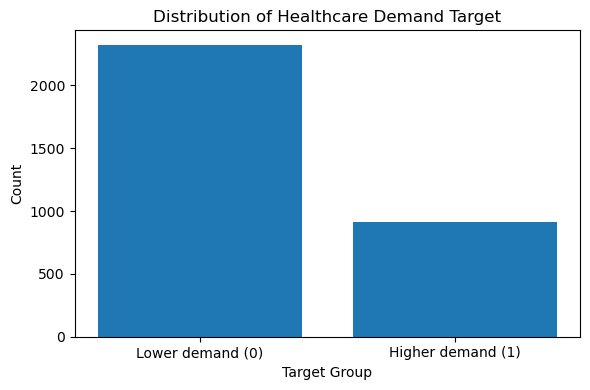

In [36]:
import matplotlib.pyplot as plt

# Create final modeling dataset
model_df = selected_simple[[
    'RIAGENDR',
    'RIDAGEYR',
    'RIDRETH1',
    'DMDEDUC2',
    'DMDMARTZ',
    'DIQ010',
    'BPQ020',
    'BPQ080',
    'MCQ160A',
    'MCQ160P',
    'MCQ220',
    'cardio_disease',
    'CDQ001',
    'CDQ010',
    'smoking_status',
    'target'
]].copy()

# Remove rows with missing target
model_df = model_df.dropna(subset=['target'])

# Remove rows with remaining missing predictor values
model_df = model_df.dropna()

# Convert target to integer
model_df['target'] = model_df['target'].astype(int)

# Count target values
target_counts = model_df['target'].value_counts().sort_index()

# Plot target distribution
plt.figure(figsize=(6, 4))
plt.bar(['Lower demand (0)', 'Higher demand (1)'], target_counts.values)

plt.xlabel('Target Group')
plt.ylabel('Count')
plt.title('Distribution of Healthcare Demand Target')

plt.tight_layout()
plt.show()

From the figure, the lower healthcare demand group is larger than the higher healthcare demand group. This indicates that the target variable is somewhat imbalanced, although both classes are still represented in the dataset.